In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil diimpor!")

Library berhasil diimpor!


In [41]:
np.random.seed(42)

X = np.random.rand(100, 1) * 10
y = 2.5 * X.squeeze() + 5 + np.random.randn(100) * 2

print("Jumlah data:", len(X))
print("Contoh X:", X[:5].flatten())
print("Contoh y:", y[:5])

Jumlah data: 100
Contoh X: [3.74540119 9.50714306 7.31993942 5.98658484 1.5601864 ]
Contoh y: [14.53759711 28.16984296 23.4833701  15.99132428  8.46112224]


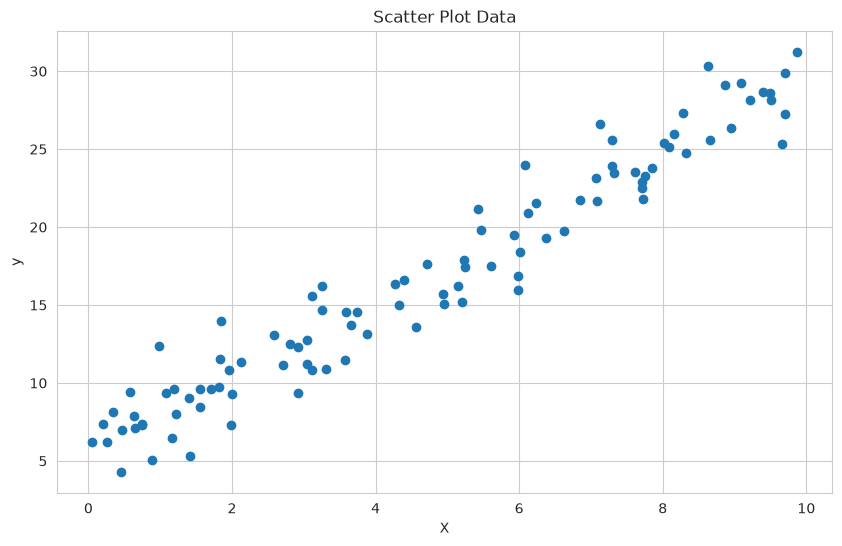

In [42]:
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter Plot Data')
plt.show()

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

Data training: 80
Data testing : 20


In [44]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model berhasil dilatih!")
print("Intercept:", model.intercept_)
print("Koefisien:", model.coef_[0])

Model berhasil dilatih!
Intercept: 5.285826638917127
Koefisien: 2.419729462992111


In [45]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Prediksi data training selesai")
print("Prediksi data testing selesai")

Prediksi data training selesai
Prediksi data testing selesai


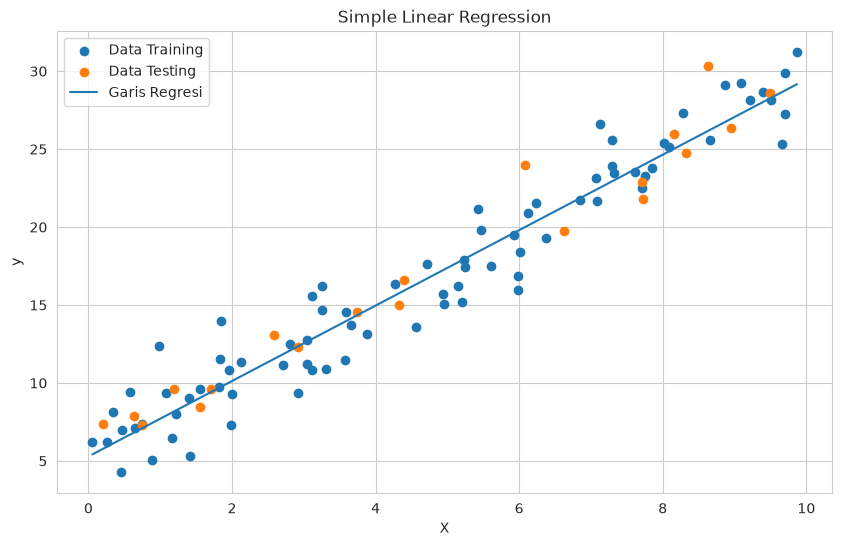

In [46]:
plt.scatter(X_train, y_train, label='Data Training')
plt.scatter(X_test, y_test, label='Data Testing')

X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)

plt.plot(X_line, y_line, label='Garis Regresi')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [47]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("=== Evaluasi Model ===")
print(f"R² Training : {r2_train:.4f}")
print(f"R² Testing  : {r2_test:.4f}")
print(f"RMSE Training: {rmse_train:.4f}")
print(f"RMSE Testing : {rmse_test:.4f}")

=== Evaluasi Model ===
R² Training : 0.9361
R² Testing  : 0.9546
RMSE Training: 1.8414
RMSE Testing : 1.6170


In [48]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("=== MAE ===")
print(f"MAE Training : {mae_train:.4f}")
print(f"MAE Testing  : {mae_test:.4f}")

=== MAE ===
MAE Training : 1.4695
MAE Testing  : 1.1827


### Interpretasi Hasil

Model Simple Linear Regression memiliki R² Testing sebesar 0.9546 atau sekitar 95,46%, sehingga model mampu menjelaskan sebagian besar variasi data. Nilai MAE sebesar 1.1827 menunjukkan rata-rata kesalahan prediksi sekitar 1,18 satuan, sedangkan RMSE sebesar 1.6170 menunjukkan kesalahan prediksi sekitar 1,62 satuan. Hasil ini menunjukkan bahwa model memiliki performa yang cukup baik dan tidak menunjukkan tanda overfitting yang serius.

In [49]:
X_new = np.array([[1], [3], [5], [7], [9]])

y_new = model.predict(X_new)

print("=== Prediksi 5 Data Baru ===")
for x, pred in zip(X_new.flatten(), y_new):
    print(f"X = {x} -> Prediksi y = {pred:.2f}")

=== Prediksi 5 Data Baru ===
X = 1 -> Prediksi y = 7.71
X = 3 -> Prediksi y = 12.55
X = 5 -> Prediksi y = 17.38
X = 7 -> Prediksi y = 22.22
X = 9 -> Prediksi y = 27.06


In [50]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df['Price'] = diabetes.target

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
print("\nNama kolom:")
print(df.columns.tolist())

Jumlah baris : 442
Jumlah kolom : 11

Nama kolom:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'Price']


In [51]:
print("=== 5 Data Pertama ===")
display(df.head())

print("\n=== Informasi Dataset ===")
df.info()

print("\n=== Statistik Dataset ===")
display(df.describe())

=== 5 Data Pertama ===


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Price
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



=== Informasi Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  Price   442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

=== Statistik Dataset ===


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Price
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [52]:
correlation = df.corr(numeric_only=True)

print("=== Korelasi dengan Price ===")
print(correlation['Price'].sort_values(ascending=False))

=== Korelasi dengan Price ===
Price    1.000000
bmi      0.586450
s5       0.565883
bp       0.441482
s4       0.430453
s6       0.382483
s1       0.212022
age      0.187889
s2       0.174054
sex      0.043062
s3      -0.394789
Name: Price, dtype: float64


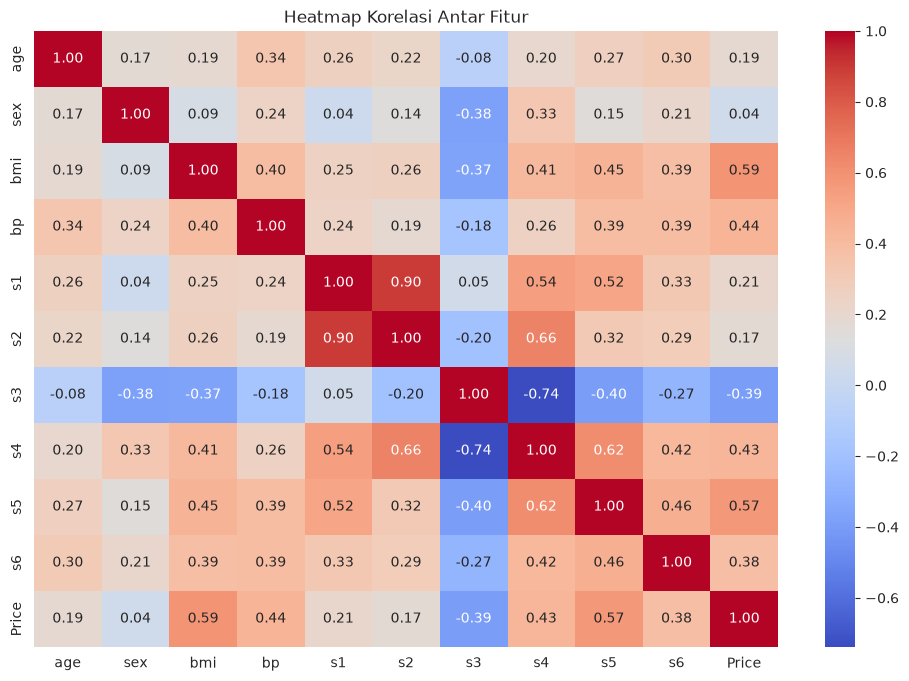

In [53]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

In [54]:
top_5_features = (
    correlation['Price']
    .drop('Price')
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("5 fitur terbaik:")
print(top_5_features)

5 fitur terbaik:
['bmi', 's5', 'bp', 's4', 's3']


In [55]:
X_all = df.drop(columns=['Price'])
y_all = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

Data training: 353
Data testing : 89


In [56]:
model_all = LinearRegression()

model_all.fit(X_train, y_train)

y_pred_all = model_all.predict(X_test)

print("Model dengan semua fitur berhasil dilatih!")
print("Jumlah fitur:", X_all.shape[1])

Model dengan semua fitur berhasil dilatih!
Jumlah fitur: 10


In [57]:
r2_all = r2_score(y_test, y_pred_all)
mae_all = mean_absolute_error(y_test, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))

print("=== Evaluasi Model Semua Fitur ===")
print(f"R²   : {r2_all:.4f}")
print(f"MAE  : {mae_all:.4f}")
print(f"RMSE : {rmse_all:.4f}")

=== Evaluasi Model Semua Fitur ===
R²   : 0.4526
MAE  : 42.7941
RMSE : 53.8534


In [58]:
X_top5 = df[top_5_features]
y_top5 = df['Price']

X_train_top5, X_test_top5, y_train_top5, y_test_top5 = train_test_split(
    X_top5,
    y_top5,
    test_size=0.2,
    random_state=42
)

model_top5 = LinearRegression()
model_top5.fit(X_train_top5, y_train_top5)

y_pred_top5 = model_top5.predict(X_test_top5)

print("Model 5 fitur terbaik berhasil dilatih!")
print("Fitur yang digunakan:", top_5_features)

Model 5 fitur terbaik berhasil dilatih!
Fitur yang digunakan: ['bmi', 's5', 'bp', 's4', 's3']


In [59]:
r2_top5 = r2_score(y_test_top5, y_pred_top5)
mae_top5 = mean_absolute_error(y_test_top5, y_pred_top5)
rmse_top5 = np.sqrt(mean_squared_error(y_test_top5, y_pred_top5))

print("=== Evaluasi Model 5 Fitur ===")
print(f"R²   : {r2_top5:.4f}")
print(f"MAE  : {mae_top5:.4f}")
print(f"RMSE : {rmse_top5:.4f}")

=== Evaluasi Model 5 Fitur ===
R²   : 0.4458
MAE  : 43.9283
RMSE : 54.1893


,Model,R2,MAE,RMSE
0,Semua Fitur,0.452603,42.794095,53.853446
1,5 Fitur Terbaik,0.445753,43.928286,54.189333


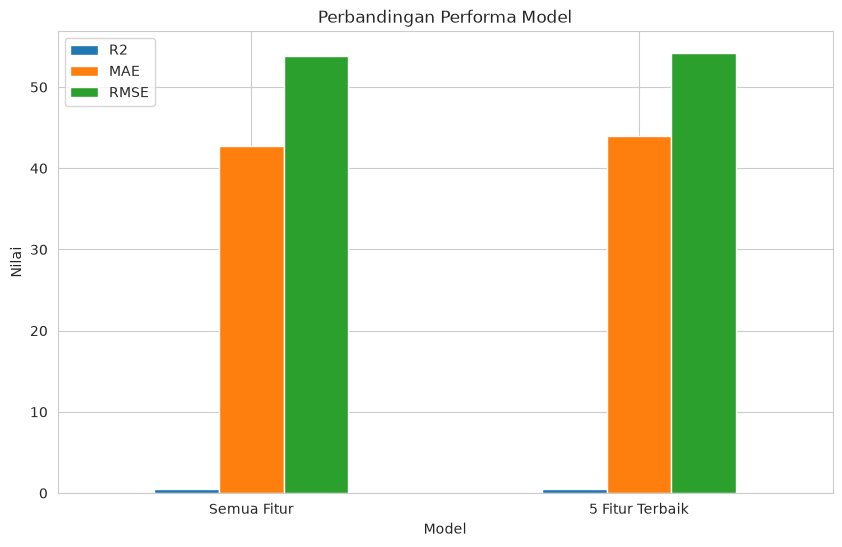

In [60]:
hasil_perbandingan = pd.DataFrame({
    'Model': ['Semua Fitur', '5 Fitur Terbaik'],
    'R2': [r2_all, r2_top5],
    'MAE': [mae_all, mae_top5],
    'RMSE': [rmse_all, rmse_top5]
})

display(hasil_perbandingan)

hasil_perbandingan.set_index('Model')[['R2', 'MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Perbandingan Performa Model')
plt.ylabel('Nilai')
plt.xticks(rotation=0)
plt.show()

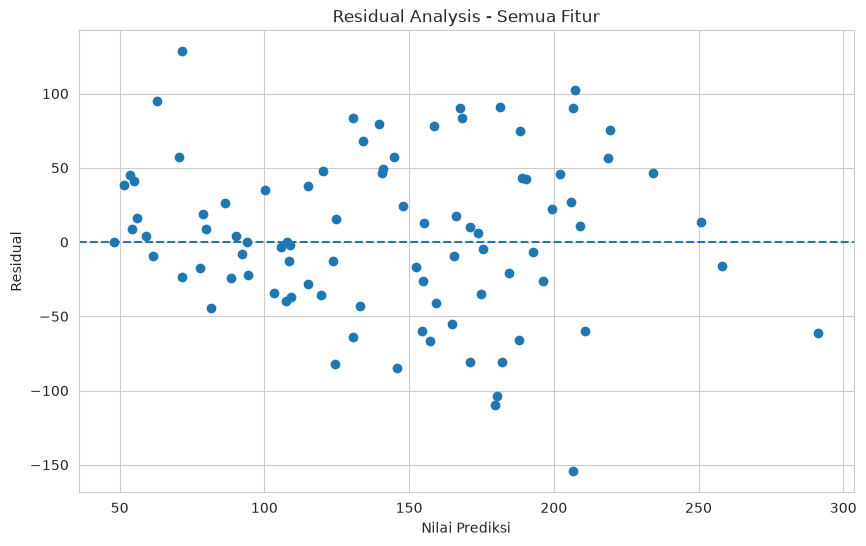

In [61]:
residuals = y_test - y_pred_all

plt.scatter(y_pred_all, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')
plt.title('Residual Analysis - Semua Fitur')
plt.show()

In [62]:
koefisien = pd.DataFrame({
    'Fitur': X_all.columns,
    'Koefisien': model_all.coef_
})

koefisien = koefisien.sort_values(
    by='Koefisien',
    ascending=False
)

display(koefisien)

,Fitur,Koefisien
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
6,s3,163.419983
9,s6,48.670657
0,age,37.904021
1,sex,-241.964362
4,s1,-931.488846


### Interpretasi Koefisien

Koefisien menunjukkan arah hubungan setiap fitur terhadap Price ketika fitur lainnya dianggap tetap.

- **s5** memiliki koefisien positif paling besar, yaitu 736.20.
- **bmi** memiliki hubungan positif dengan koefisien 542.43.
- **bp** juga memiliki hubungan positif dengan Price sebesar 347.70.
- **s1** memiliki koefisien negatif paling besar, yaitu -931.49.
- **sex** memiliki koefisien negatif sebesar -241.96.
- Koefisien positif menunjukkan bahwa kenaikan fitur cenderung meningkatkan nilai Price, sedangkan koefisien negatif menunjukkan hubungan sebaliknya.

Secara keseluruhan, model dengan semua fitur memiliki performa sedikit lebih baik dibandingkan model 5 fitur karena memiliki R² lebih tinggi serta MAE dan RMSE lebih rendah.

In [63]:
np.random.seed(42)

X_poly = np.linspace(-3, 3, 100).reshape(-1, 1)

y_poly = (
    0.5 * X_poly**2
    + X_poly
    + 2
    + np.random.randn(100, 1) * 0.5
)

print("Jumlah data:", len(X_poly))

Jumlah data: 100


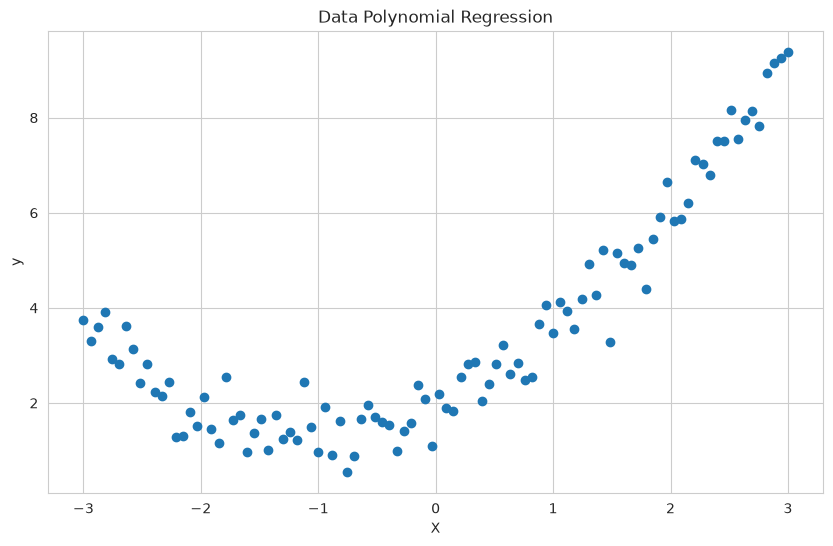

In [64]:
plt.scatter(X_poly, y_poly)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Data Polynomial Regression')
plt.show()

In [65]:
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y_poly.ravel(),
    test_size=0.2,
    random_state=42
)

degrees = range(1, 11)

r2_train_list = []
r2_test_list = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)

    X_train_degree = poly.fit_transform(X_train_poly)
    X_test_degree = poly.transform(X_test_poly)

    model_degree = LinearRegression()
    model_degree.fit(X_train_degree, y_train_poly)

    train_pred = model_degree.predict(X_train_degree)
    test_pred = model_degree.predict(X_test_degree)

    r2_train_list.append(r2_score(y_train_poly, train_pred))
    r2_test_list.append(r2_score(y_test_poly, test_pred))

print("Perbandingan degree selesai.")

Perbandingan degree selesai.


In [66]:
hasil_degree = pd.DataFrame({
    'Degree': list(degrees),
    'R² Training': r2_train_list,
    'R² Testing': r2_test_list
})

display(hasil_degree)

,Degree,R² Training,R² Testing
0,1,0.609315,0.455970
1,2,0.962379,0.955124
2,3,0.964314,0.956383
3,4,0.965058,0.954019
4,5,0.965138,0.952988
5,6,0.965145,0.952756
6,7,0.965201,0.952644
7,8,0.965498,0.954955
8,9,0.967104,0.946314
9,10,0.967231,0.940809


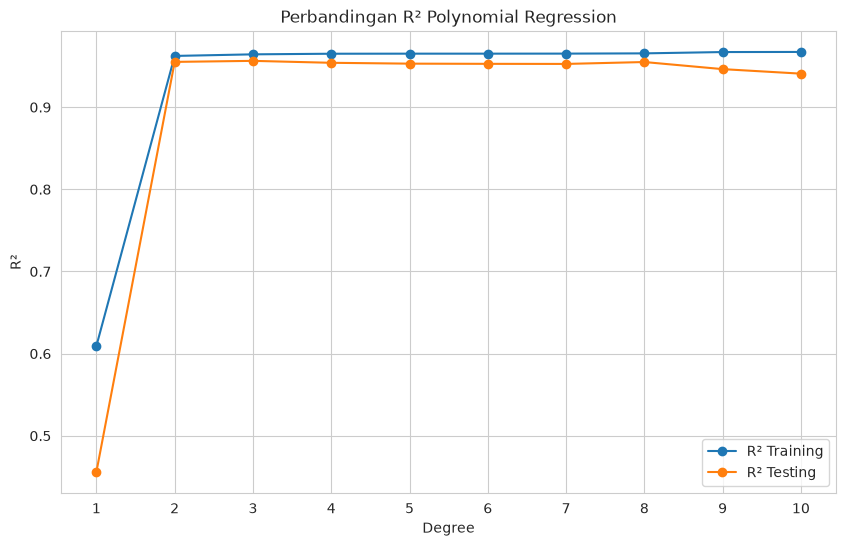

In [67]:
plt.plot(degrees, r2_train_list, marker='o', label='R² Training')
plt.plot(degrees, r2_test_list, marker='o', label='R² Testing')

plt.xlabel('Degree')
plt.ylabel('R²')
plt.title('Perbandingan R² Polynomial Regression')
plt.xticks(list(degrees))
plt.legend()
plt.show()

In [68]:
degree_optimal = 3

poly3 = PolynomialFeatures(degree=degree_optimal)

X_train_3 = poly3.fit_transform(X_train_poly)
X_test_3 = poly3.transform(X_test_poly)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_3, y_train_poly)

y_train_pred_3 = model_poly3.predict(X_train_3)
y_test_pred_3 = model_poly3.predict(X_test_3)

print("Model Polynomial Degree 3 berhasil dibuat!")

Model Polynomial Degree 3 berhasil dibuat!


In [69]:
r2_train_3 = r2_score(y_train_poly, y_train_pred_3)
r2_test_3 = r2_score(y_test_poly, y_test_pred_3)

mae_3 = mean_absolute_error(y_test_poly, y_test_pred_3)
mse_3 = mean_squared_error(y_test_poly, y_test_pred_3)
rmse_3 = np.sqrt(mse_3)

print("=== Evaluasi Polynomial Regression Degree 3 ===")
print(f"R² Training : {r2_train_3:.4f}")
print(f"R² Testing  : {r2_test_3:.4f}")
print(f"MAE         : {mae_3:.4f}")
print(f"MSE         : {mse_3:.4f}")
print(f"RMSE        : {rmse_3:.4f}")

=== Evaluasi Polynomial Regression Degree 3 ===
R² Training : 0.9643
R² Testing  : 0.9564
MAE         : 0.2916
MSE         : 0.1506
RMSE        : 0.3880


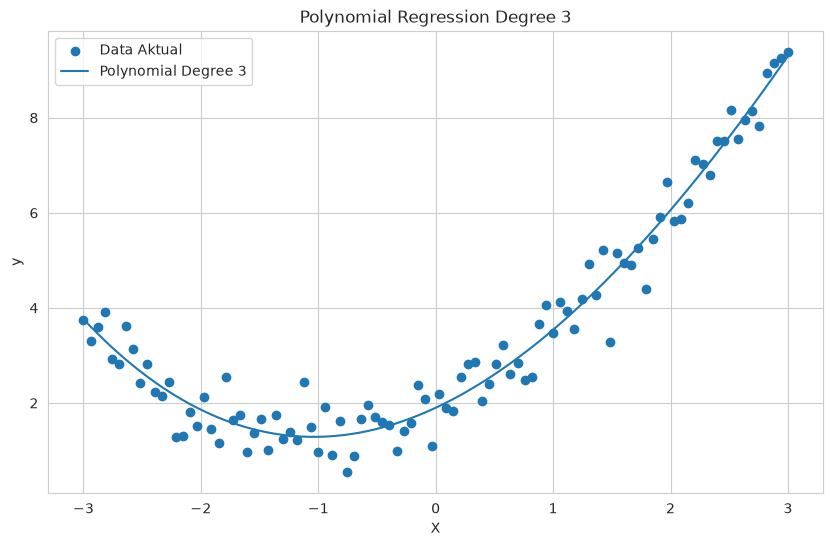

In [70]:
# Membuat garis prediksi yang halus
X_plot = np.linspace(X_poly.min(), X_poly.max(), 200).reshape(-1, 1)

X_plot_3 = poly3.transform(X_plot)
y_plot_3 = model_poly3.predict(X_plot_3)

plt.scatter(X_poly, y_poly, label='Data Aktual')
plt.plot(X_plot, y_plot_3, label='Polynomial Degree 3')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Degree 3')
plt.legend()
plt.show()

### Interpretasi Polynomial Regression

Model Polynomial Regression Degree 3 memiliki R² Training sebesar 0.9643 dan R² Testing sebesar 0.9564. Nilai ini menunjukkan bahwa model mampu menjelaskan sebagian besar variasi data dengan baik.

Nilai MAE sebesar 0.2916 dan RMSE sebesar 0.3880 menunjukkan bahwa kesalahan prediksi relatif kecil. Degree 1 mengalami underfitting karena R² rendah, sedangkan degree yang terlalu tinggi mulai menunjukkan tanda overfitting karena nilai R² training meningkat tetapi R² testing menurun.

Berdasarkan hasil pengujian, Degree 3 dipilih sebagai model terbaik karena memiliki R² Testing paling tinggi, yaitu 0.9564.

In [71]:
# Data pengalaman kerja dan gaji
data_gaji = pd.DataFrame({
    'Pengalaman': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Gaji': [3.2, 3.8, 4.5, 5.0, 5.8, 6.5, 7.2, 8.0, 8.8, 9.5]
})

display(data_gaji)

,Pengalaman,Gaji
0,1,3.2
1,2,3.8
2,3,4.5
3,4,5.0
4,5,5.8
5,6,6.5
6,7,7.2
7,8,8.0
8,9,8.8
9,10,9.5


In [72]:
X_gaji = data_gaji[['Pengalaman']]
y_gaji = data_gaji['Gaji']

X_train_gaji, X_test_gaji, y_train_gaji, y_test_gaji = train_test_split(
    X_gaji,
    y_gaji,
    test_size=0.2,
    random_state=42
)

print("Data training :", len(X_train_gaji))
print("Data testing  :", len(X_test_gaji))

Data training : 8
Data testing  : 2


In [73]:
model_gaji = LinearRegression()

model_gaji.fit(X_train_gaji, y_train_gaji)

y_pred_gaji = model_gaji.predict(X_test_gaji)

print("Model berhasil dilatih!")
print(f"Intercept : {model_gaji.intercept_:.2f}")
print(f"Koefisien : {model_gaji.coef_[0]:.2f}")

Model berhasil dilatih!
Intercept : 2.35
Koefisien : 0.70


In [74]:
r2_gaji = r2_score(y_test_gaji, y_pred_gaji)
mae_gaji = mean_absolute_error(y_test_gaji, y_pred_gaji)
mse_gaji = mean_squared_error(y_test_gaji, y_pred_gaji)
rmse_gaji = np.sqrt(mse_gaji)

print("=== Evaluasi Model Prediksi Gaji ===")
print(f"R²   : {r2_gaji:.4f}")
print(f"MAE  : {mae_gaji:.4f}")
print(f"MSE  : {mse_gaji:.4f}")
print(f"RMSE : {rmse_gaji:.4f}")

=== Evaluasi Model Prediksi Gaji ===
R²   : 0.9985
MAE  : 0.0875
MSE  : 0.0093
RMSE : 0.0966


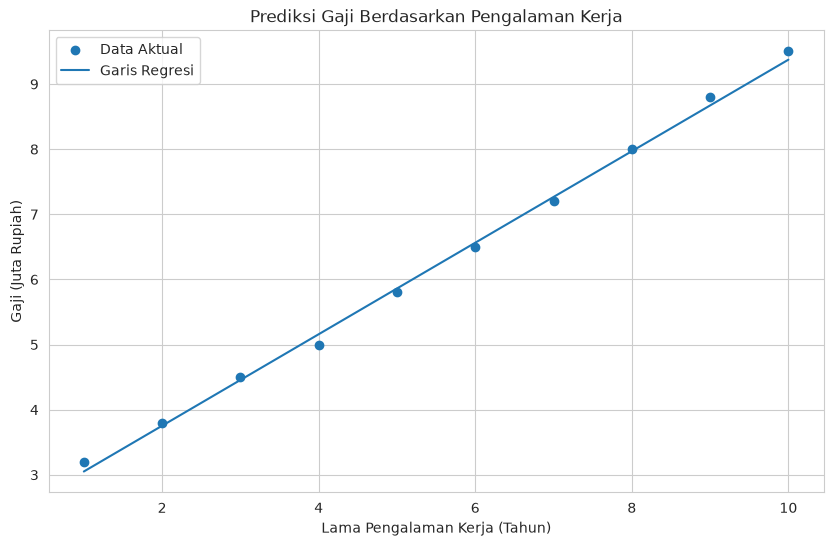

In [75]:
plt.scatter(
    data_gaji['Pengalaman'],
    data_gaji['Gaji'],
    label='Data Aktual'
)

plt.plot(
    data_gaji['Pengalaman'],
    model_gaji.predict(data_gaji[['Pengalaman']]),
    label='Garis Regresi'
)

plt.xlabel('Lama Pengalaman Kerja (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.title('Prediksi Gaji Berdasarkan Pengalaman Kerja')
plt.legend()
plt.show()

In [76]:
pengalaman_baru = pd.DataFrame({
    'Pengalaman': [12]
})

prediksi_gaji = model_gaji.predict(pengalaman_baru)

print(f"Prediksi gaji untuk 12 tahun pengalaman: {prediksi_gaji[0]:.2f} juta rupiah")

Prediksi gaji untuk 12 tahun pengalaman: 10.78 juta rupiah


### Kesimpulan Task 4

Linear Regression dapat digunakan untuk memprediksi gaji berdasarkan lama pengalaman kerja. Dari hasil model, semakin lama pengalaman kerja maka gaji cenderung meningkat. Model juga dapat digunakan untuk memperkirakan gaji berdasarkan jumlah tahun pengalaman yang baru.

## Kesimpulan

Pada praktikum ini telah dipelajari Linear Regression dan Polynomial Regression. Linear Regression digunakan untuk melihat hubungan antara fitur dan target serta melakukan prediksi. Polynomial Regression dapat menangkap hubungan data yang berbentuk melengkung dan membantu memahami underfitting serta overfitting.

Pada Simple Linear Regression diperoleh R² Testing sebesar 0.9546. Pada Polynomial Regression, Degree 3 menjadi model terbaik dengan R² Testing sebesar 0.9564. Evaluasi menggunakan R², MAE, MSE, dan RMSE membantu mengetahui seberapa baik model dalam melakukan prediksi.

Selain itu, Linear Regression diterapkan pada contoh prediksi gaji berdasarkan pengalaman kerja. Hasilnya menunjukkan bahwa pengalaman kerja dapat digunakan sebagai salah satu faktor untuk memperkirakan gaji.